In [1]:
import numpy as np
import pandas as pd
import random

import torch
import torch.nn as nn
import normflows as nf
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from scipy.stats import gaussian_kde
from scipy.special import gamma
import math

In [2]:
# :::::::::::::::::::::::::::::::::::
# Simulation Setup
# :::::::::::::::::::::::::::::::::::
np.random.seed(0)
sigma = 0.1
tau = 0.8
omega = 5

n1 = 5000
n2 = 5000

In [3]:
# :::::::::::::::::::::::::::::::::::
# Generating X Samples
# :::::::::::::::::::::::::::::::::::
def x_sample_generator(n = 1):
    t = np.random.gamma(shape=1/4, scale=1.0, size=n)
    r = t ** (1/4)
    u = np.random.binomial(n=1, p=0.5, size=n)
    sign = np.where(u == 1, 1, -1)
    x = r * sign
    return x.reshape(-1, 1)

# :::::::::::::::::::::::::::::::::::
# Generating (X,Y) Samples
# :::::::::::::::::::::::::::::::::::
def xy_sample_generator(n=1):
    x = x_sample_generator(n).ravel()
    y = np.random.normal(loc=np.sin(2*x)**3, scale=sigma, size=n)
    return np.column_stack((x, y))

XY_samples = xy_sample_generator(n1)

# :::::::::::::::::::::::::::::::::::
# Generating (X,Z) Samples
# :::::::::::::::::::::::::::::::::::
def xz_sample_generator(n=1):
    x = x_sample_generator(n).ravel()
    z = np.random.normal(loc=omega * np.sin(np.pi * x), scale=tau, size=n)
    return np.column_stack((x, z))

XZ_samples = xz_sample_generator(n2)

# :::::::::::::::::::::::::::::::::::
# Resampling function
# :::::::::::::::::::::::::::::::::::
def resample(pairs, n=1):
    """
    pairs: NumPy array of shape (m, 2), e.g. output of xz_sample_generator(n) or xy_sample_generator(n)
    n: size of the resampled batch 

    Returns: NumPy array of shape (n, 2) which serves as inputs in Stage 1 models
    """
    pairs = np.asarray(pairs)
    idx = np.random.choice(pairs.shape[0], size=n, replace=True)
    return pairs[idx].astype(np.float32)

# :::::::::::::::::::::::::::::::::::
# Density Functions (Used for Plotting and Comparisons)
# :::::::::::::::::::::::::::::::::::
# def log_f_x(x):
#     return np.log(2 / gamma(1/4)) - x**4
# def log_f_y_given_x(y, x):
#     return -0.5 * np.log(2 * np.pi) - np.log(sigma) - 0.5 * ((y - np.sin(2*x)**3) / sigma) ** 2
# def log_joint_xy(x, y):
#     return log_f_x(x) + log_f_y_given_x(y, x)
# def log_f_z_given_x(z, x):
#      return -0.5 * np.log(2 * np.pi) - np.log(tau) - 0.5 * ((z - omega*np.sin(np.pi*x)) / tau) ** 2
# def log_joint_xz(x, z):
#     return log_f_x(x) + log_f_z_given_x(z, x)

def f_x(x):
    return (2.0 / gamma(0.25)) * np.exp(-x**4)
def f_y_given_x(y, x):
    return (1.0 / (np.sqrt(2*np.pi)*sigma)) * np.exp(-0.5 * ((y - np.sin(2*x)**3) / sigma)**2)
def f_z_given_x(z, x):
    mu = omega * np.sin(np.pi * x)
    return (1.0 / (np.sqrt(2*np.pi)*tau)) * np.exp(-0.5 * ((z - mu) / tau)**2)

def f_xy(x, y):
    return f_x(x) * f_y_given_x(y, x)

def f_xz(x, z):
    return f_x(x) * f_z_given_x(z, x)

def make_f_yz(x_min=-3.0, x_max=3.0, nx=2000):
    """
    Returns a function f_YZ(y, z) = ∫ f_X(x) f(y|x) f(z|x) dx

    y, z can be scalars, 1D arrays of same shape,
    or broadcastable arrays (e.g. meshgrids).
    """
    x_int = np.linspace(x_min, x_max, nx)

    def f_yz(y, z):
        y = np.asarray(y)
        z = np.asarray(z)
        Y, Z = np.broadcast_arrays(y, z)
        Y_flat = Y.ravel()[None, :]
        Z_flat = Z.ravel()[None, :]

        X = x_int[:, None]
        integrand = f_x(X) * f_y_given_x(Y_flat, X) * f_z_given_x(Z_flat, X)
        vals_flat = np.trapezoid(integrand, x_int, axis=0)
        return vals_flat.reshape(Y.shape)

    return f_yz
def make_f_y(x_min=-3.0, x_max=3.0, nx=2000):
    """
    Returns a function f_Y(y) = ∫ f_X(x) f(y|x) dx
    """
    x_int = np.linspace(x_min, x_max, nx)

    def f_y(y):
        y = np.asarray(y)
        X = x_int[:, None]
        Y = y[None, :]
        integrand = f_x(X) * f_y_given_x(Y, X)
        vals = np.trapezoid(integrand, x_int, axis=0)
        return vals
    return f_y
def make_f_z(x_min=-3.0, x_max=3.0, nx=2000):
    """
    Returns a function f_Z(z) = ∫ f_X(x) f(z|x) dx
    """
    x_int = np.linspace(x_min, x_max, nx)

    def f_z(z):
        z = np.asarray(z)
        X = x_int[:, None]
        Z = z[None, :]
        integrand = f_x(X) * f_z_given_x(Z, X)
        vals = np.trapezoid(integrand, x_int, axis=0)
        return vals

    return f_z
f_y = make_f_y()
f_z = make_f_z()
f_yz = make_f_yz()

## Stage 1 Model 1: Learning the joint density of (X,Y)

100%|██████████| 8000/8000 [00:27<00:00, 292.87it/s]


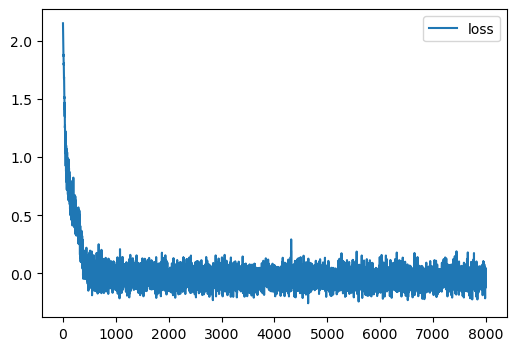

In [4]:
torch.manual_seed(0)

latent_size = 2
# :::::::::::::::::::::::::::::::::::
# Flow Structure
# :::::::::::::::::::::::::::::::::::
K = 2 # Number of Layers
flows = []
for i in range(K):
    flows += [nf.flows.AutoregressiveRationalQuadraticSpline(
    num_input_channels=latent_size,
    num_blocks=3,
    num_hidden_channels=16,
    num_bins=8,
    tail_bound=10,
    activation=torch.nn.ReLU,
    dropout_probability=0.0,
    permute_mask=(i % 2 == 0),
    init_identity=True
    )]
    flows += [nf.flows.ActNorm(latent_size)]

q0 = nf.distributions.DiagGaussian(latent_size) # Base Distribution
nfm_1 = nf.NormalizingFlow(q0=q0, flows=flows) # Normalizing Flows Model
device = torch.device('cpu') # Other Options Include 'Cuda' or 'GPU'
nfm_1 = nfm_1.to(device).float() # float instead of double for faster execution

with torch.no_grad(): # Helps Stablize the ACTNORM Layer
    _ = nfm_1.sample(5000)


max_iter = 8000 # Number of Iterations
num_samples = 200 # Batch Size
loss_hist = np.array([])
optimizer = torch.optim.Adam(nfm_1.parameters(), lr=5e-4, weight_decay=1e-6)

for it in tqdm(range(max_iter)):
    optimizer.zero_grad()
    loss = nfm_1.forward_kld(torch.tensor(resample(XY_samples, num_samples))) # A random sample with replacement from the pool of (X,Y) samples
    
    if ~(torch.isnan(loss) | torch.isinf(loss)):
        loss.backward()
        optimizer.step()
    
    loss_hist = np.append(loss_hist, loss.to('cpu').data.numpy())

plt.figure(figsize=(6, 4))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()

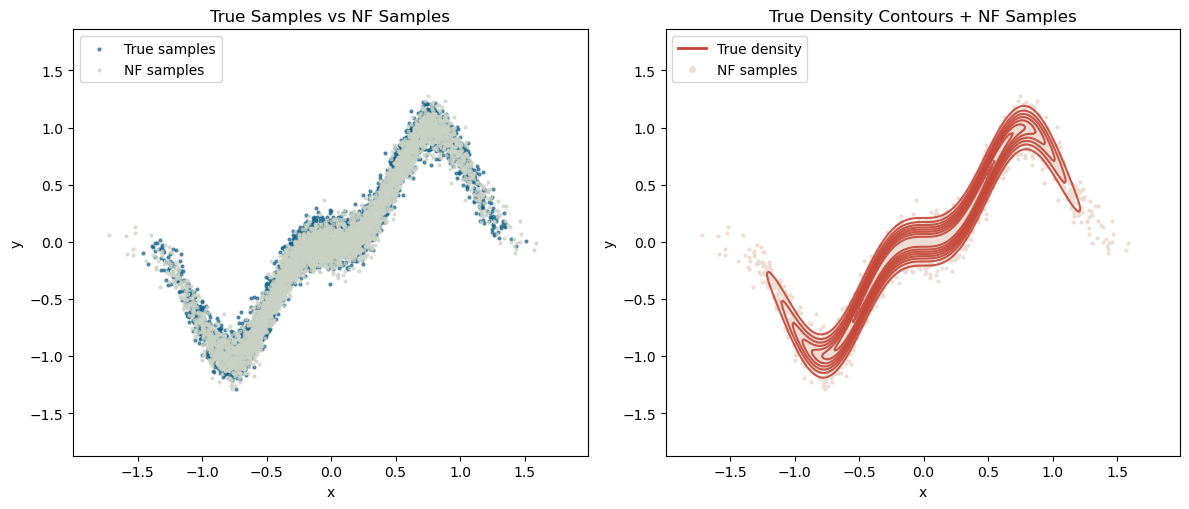

In [5]:
# :::::::::::::::::::::::::::::::::::
# Generating samples from the NF model
# :::::::::::::::::::::::::::::::::::
nfm_1.eval()
with torch.no_grad():
    xy_nf_samples, _ = nfm_1.sample(5000)

xy_nf_samples = xy_nf_samples.cpu().numpy()

x_nf, y_nf = xy_nf_samples[:, 0], xy_nf_samples[:, 1]
x_tr, y_tr = XY_samples[:, 0], XY_samples[:, 1]

# :::::::::::::::::::::::::::::::::::
# Plotting
# :::::::::::::::::::::::::::::::::::

x_all = np.concatenate([x_tr, x_nf])
y_all = np.concatenate([y_tr, y_nf])

x_min, x_max = np.percentile(x_all, [1, 99])
y_min, y_max = np.percentile(y_all, [1, 99])

pad_x = 0.35 * (x_max - x_min)
pad_y = 0.35 * (y_max - y_min)

nx, ny = 250, 250
xg = np.linspace(x_min - pad_x, x_max + pad_x, nx)
yg = np.linspace(y_min - pad_y, y_max + pad_y, ny)
XX, YY = np.meshgrid(xg, yg)

Joint_true = f_xy(XX, YY)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))

# ------------------------------------------------------------
# LEFT: True vs NF Samples
# ------------------------------------------------------------
axes[0].scatter(x_tr, y_tr, s=4, alpha=0.65, color="#186287", label="True samples")
axes[0].scatter(x_nf, y_nf, s=4, alpha=0.65, color="#cad2c5", label="NF samples")
axes[0].set_title("True Samples vs NF Samples")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend(loc="upper left")

# ------------------------------------------------------------
# RIGHT: True Density Contours + NF Samples
# ------------------------------------------------------------
cs = axes[1].contour(
    XX, YY, Joint_true,
    levels=8,
    colors="#c44536",
    linewidths=1.5,
    alpha=0.9
)

axes[1].scatter(x_nf, y_nf, s=4, alpha=0.95, color="#edddd4")
contour_line = Line2D([0], [0], color="#c44536", lw=2)
nf_points = Line2D([0], [0], marker='o', color='w', markerfacecolor="#edddd4", markersize=6)

axes[1].legend([contour_line, nf_points], ["True density", "NF samples"], loc="upper left")

axes[1].set_title("True Density Contours + NF Samples")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

for ax in axes:
    ax.set_xlim(x_min - pad_x, x_max + pad_x)
    ax.set_ylim(y_min - pad_y, y_max + pad_y)

plt.tight_layout()
plt.show()


## Stage 1 Model 2: Learning the joint density of (X,Z)

100%|██████████| 8000/8000 [00:27<00:00, 291.82it/s]


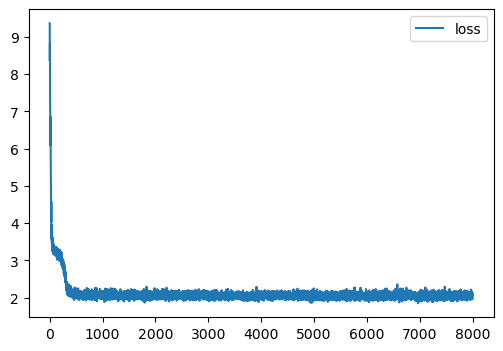

In [6]:
torch.manual_seed(0)

latent_size = 2
K = 2

flows = []
for i in range(K):
    flows += [nf.flows.AutoregressiveRationalQuadraticSpline(
    num_input_channels=latent_size,
    num_blocks=3,
    num_hidden_channels=16,
    num_bins=8,
    tail_bound=10,
    activation=torch.nn.ReLU,
    dropout_probability=0.0,
    permute_mask=(i % 2 == 0),
    init_identity=True
    )]
    flows += [nf.flows.ActNorm(latent_size)]

q0 = nf.distributions.DiagGaussian(latent_size)
nfm_2 = nf.NormalizingFlow(q0=q0, flows=flows)
device = torch.device('cpu')
nfm_2 = nfm_2.to(device).float()

with torch.no_grad():
    _ = nfm_2.sample(5000)


max_iter = 8000
num_samples = 200
loss_hist = np.array([])
optimizer = torch.optim.Adam(nfm_2.parameters(), lr=5e-4, weight_decay=1e-6)

for it in tqdm(range(max_iter)):
    optimizer.zero_grad()
    loss = nfm_2.forward_kld(torch.tensor(resample(XZ_samples, num_samples)))
    
    if ~(torch.isnan(loss) | torch.isinf(loss)):
        loss.backward()
        optimizer.step()
    
    loss_hist = np.append(loss_hist, loss.to('cpu').data.numpy())

plt.figure(figsize=(6, 4))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()

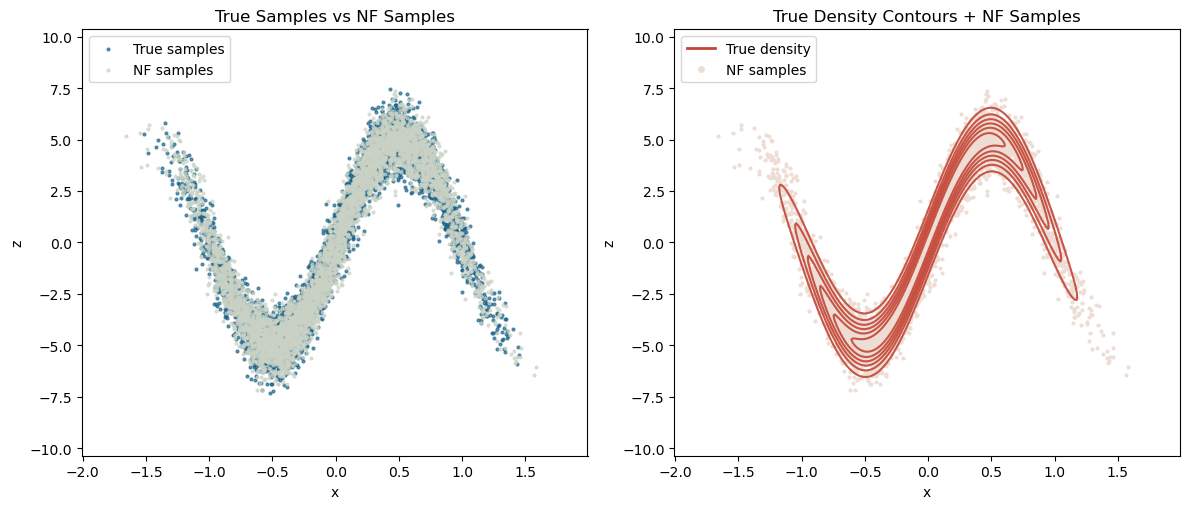

In [7]:
# :::::::::::::::::::::::::::::::::::
# Generating samples from the NF model
# :::::::::::::::::::::::::::::::::::
nfm_2.eval()
with torch.no_grad():
    xz_nf_samples, _ = nfm_2.sample(5000)

xz_nf_samples = xz_nf_samples.cpu().numpy()

x_nf, z_nf = xz_nf_samples[:, 0], xz_nf_samples[:, 1]
x_tr, z_tr = XZ_samples[:, 0], XZ_samples[:, 1]

# :::::::::::::::::::::::::::::::::::
# Plotting
# :::::::::::::::::::::::::::::::::::

x_all = np.concatenate([x_tr, x_nf])
z_all = np.concatenate([z_tr, z_nf])

x_min, x_max = np.percentile(x_all, [1, 99])
z_min, z_max = np.percentile(z_all, [1, 99])

pad_x = 0.35 * (x_max - x_min)
pad_z = 0.35 * (z_max - z_min)

nx, ny = 250, 250
xg = np.linspace(x_min - pad_x, x_max + pad_x, nx)
zg = np.linspace(z_min - pad_z, z_max + pad_z, ny)
XX, ZZ = np.meshgrid(xg, zg)

Joint_true = f_xz(XX, ZZ)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))

axes[0].scatter(x_tr, z_tr, s=4, alpha=0.65, color="#186287", label="True samples")
axes[0].scatter(x_nf, z_nf, s=4, alpha=0.65, color="#cad2c5", label="NF samples")
axes[0].set_title("True Samples vs NF Samples")
axes[0].set_xlabel("x")
axes[0].set_ylabel("z")
axes[0].legend(loc="upper left")

cs = axes[1].contour(
    XX, ZZ, Joint_true,
    levels=8,
    colors="#c44536",
    linewidths=1.5,
    alpha=0.9
)

axes[1].scatter(x_nf, z_nf, s=4, alpha=0.95, color="#edddd4")
contour_line = Line2D([0], [0], color="#c44536", lw=2)
nf_points = Line2D([0], [0], marker='o', color='w', markerfacecolor="#edddd4", markersize=6)

axes[1].legend([contour_line, nf_points], ["True density", "NF samples"], loc="upper left")

axes[1].set_title("True Density Contours + NF Samples")
axes[1].set_xlabel("x")
axes[1].set_ylabel("z")

for ax in axes:
    ax.set_xlim(x_min - pad_x, x_max + pad_x)
    ax.set_ylim(z_min - pad_z, z_max + pad_z)

plt.tight_layout()
plt.show()


## Stage 2 Final Model: Learning the joint density of (X,Y,Z)

100%|██████████| 25000/25000 [08:43<00:00, 47.72it/s]


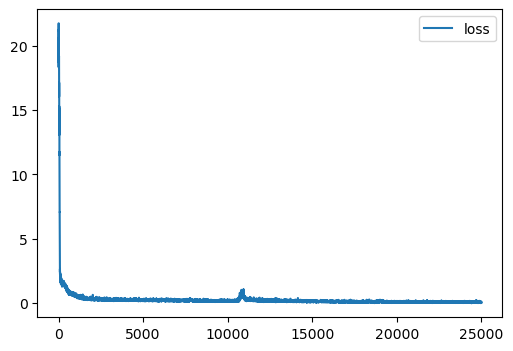

In [8]:
torch.manual_seed(0)

latent_size = 3
# Flow Structure
K = 3
flows = []
for i in range(K):
        flows += [nf.flows.AutoregressiveRationalQuadraticSpline(num_input_channels = latent_size,
                                                                 num_blocks = 3, num_hidden_channels = 12,
                                                                 num_bins=10, tail_bound = 10, init_identity=True)]
        flows += [nf.flows.LULinearPermute(latent_size)]
        flows += [nf.flows.ActNorm(latent_size)]

class Target_Distribution(nn.Module):
    def __init__(self):
        super().__init__()

    def log_prob(self, t):
        # t: (batch, 3) with [x, y, z]

        x = t[:, 0]
        y = t[:, 1]
        z = t[:, 2]

        # pack pairs
        xy = torch.stack([x, y], dim=1)
        xz = torch.stack([x, z], dim=1)

        log_xy = globals()['nfm_1'].log_prob(xy)
        log_xz = globals()['nfm_2'].log_prob(xz)
        log_fx = (math.log(2.0) - math.lgamma(0.25)) - x**4

        out = log_xy + log_xz - log_fx
        out[~torch.isfinite(out)] = torch.tensor(-1e50, dtype=torch.float32, device=device)
        return out


base= nf.distributions.DiagGaussian(latent_size) # Base distribution
target = Target_Distribution() # Need to specifying a target for reverse KL models

nfm = nf.NormalizingFlow(q0=base, flows=flows, p=target)
nfm = nfm.to(device)
nfm = nfm.float()

nfm_1 = nfm_1.to(device).float().eval()
for p in nfm_1.parameters():
        p.requires_grad_(False)
nfm_2 = nfm_2.to(device).float().eval()
for p in nfm_2.parameters():
        p.requires_grad_(False)


with torch.no_grad():
    _ = nfm.sample(1000)
    
# Training Setup
max_iter = 25000
num_samples0 = 200
lr = 5e-4

loss_hist = np.array([])
optimizer = torch.optim.Adam(nfm.parameters(), lr=lr, weight_decay=1e-6)

for it in tqdm(range(max_iter)):
    optimizer.zero_grad()
    loss = nfm.reverse_kld(num_samples = num_samples0)
    
    if torch.isnan(loss) or torch.isinf(loss):
        print(f"⚠️ NaN or Inf detected in loss at iteration {it}")
        continue 

    if ~(torch.isnan(loss) | torch.isinf(loss)):
        loss.backward()
        optimizer.step()

    loss_hist = np.append(loss_hist, loss.to('cpu').data.numpy())
    
plt.figure(figsize=(6, 4))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()


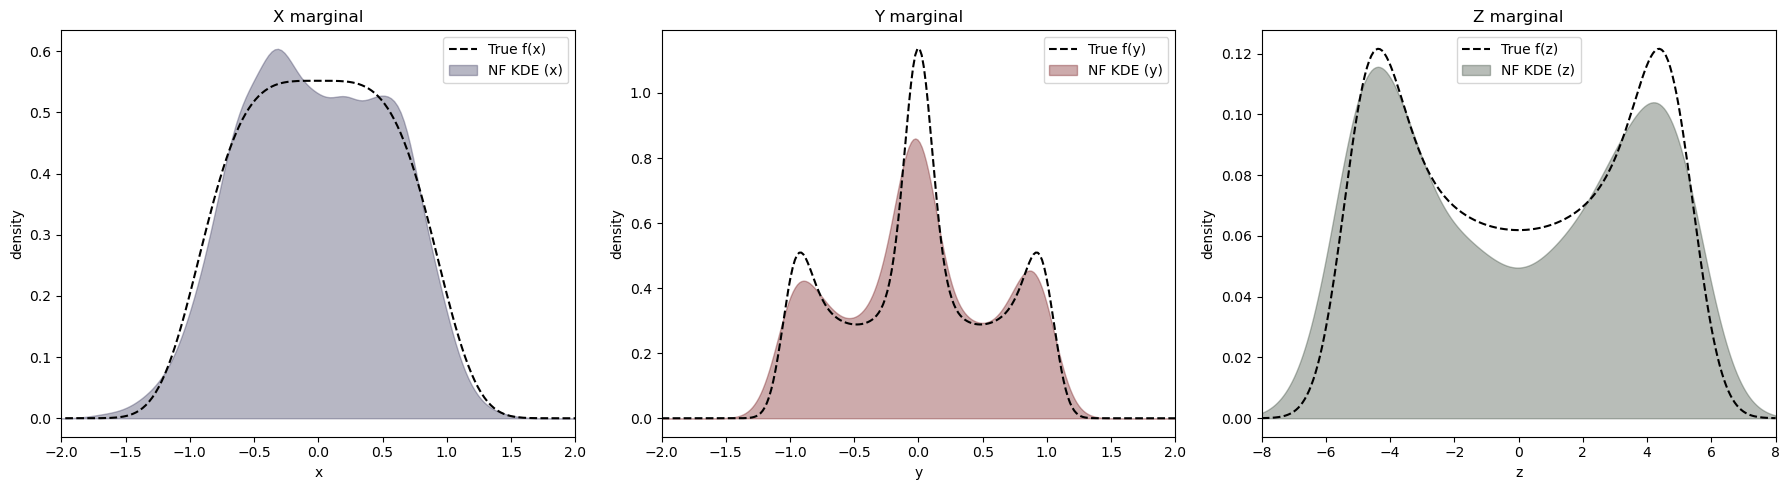

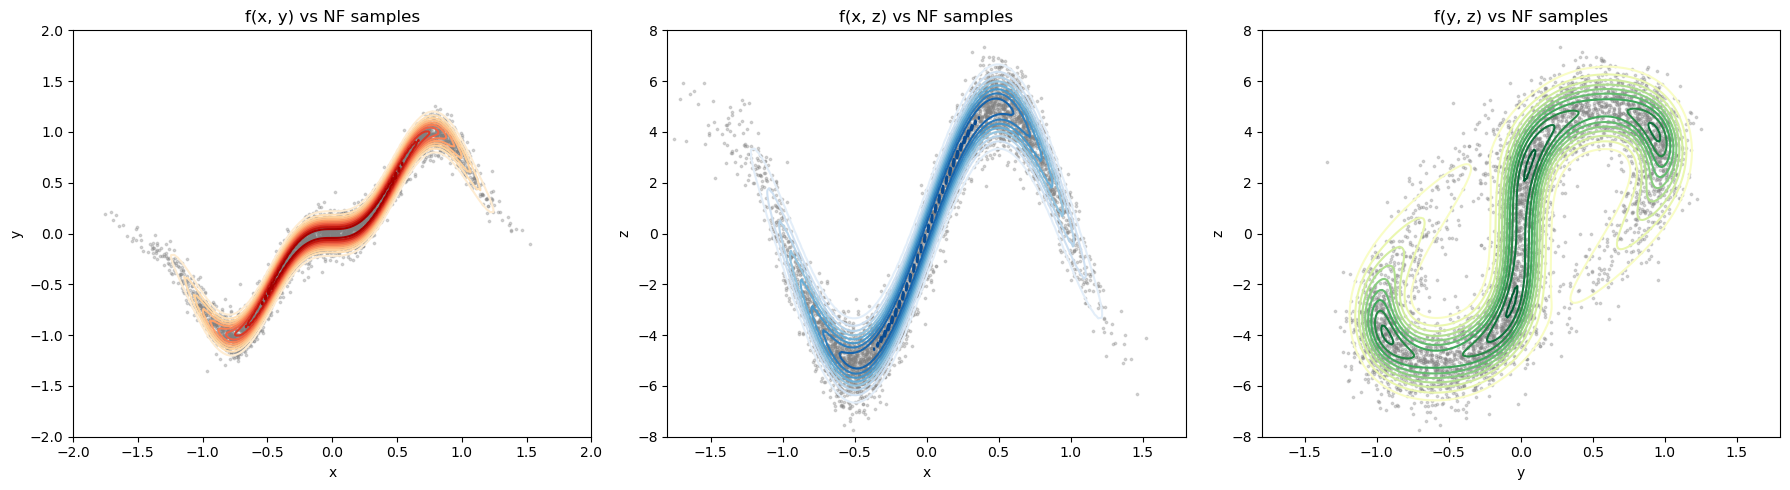

In [9]:
torch.manual_seed(1)
np.random.seed(1)
# :::::::::::::::::::::::::::::::::::
# Generating samples from the final NF model
# :::::::::::::::::::::::::::::::::::
nfm.eval()
nf_samples , _ = nfm.sample(5000)
nf_samples = nf_samples.detach().cpu().numpy()
x_nf, y_nf, z_nf = nf_samples[:, 0], nf_samples[:, 1], nf_samples[:, 2]

# :::::::::::::::::::::::::::::::::::
# Plotting
# :::::::::::::::::::::::::::::::::::
xg = np.linspace(-3,  3, 240)
yg = np.linspace(-2,  2, 240)
zg = np.linspace(-8,  8, 240)

fx_true = f_x(xg)
fy_true = f_y(yg)
fz_true = f_z(zg)

# KDEs from NF samples
kde_x = gaussian_kde(x_nf)
kde_y = gaussian_kde(y_nf)
kde_z = gaussian_kde(z_nf)
fx_kde = kde_x(xg)
fy_kde = kde_y(yg)
fz_kde = kde_z(zg)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# X marginal
axes[0].plot(xg, fx_true, linestyle="--", color="black", label="True f(x)")
axes[0].fill_between(xg, fx_kde, color="#333258", alpha=0.35, label="NF KDE (x)")
axes[0].set_xlim(-2, 2)
axes[0].set_xlabel("x"); axes[0].set_ylabel("density")
axes[0].set_title("X marginal")
axes[0].legend()

# Y marginal
axes[1].plot(yg, fy_true, linestyle="--", color="black", label="True f(y)")
axes[1].fill_between(yg, fy_kde, color="#711013", alpha=0.35, label="NF KDE (y)")
axes[1].set_xlim(-2, 2)
axes[1].set_xlabel("y"); axes[1].set_ylabel("density")
axes[1].set_title("Y marginal")
axes[1].legend()

# Z marginal
axes[2].plot(zg, fz_true, linestyle="--", color="black", label="True f(z)")
axes[2].fill_between(zg, fz_kde, color="#344435", alpha=0.35, label="NF KDE (z)")
axes[2].set_xlim(-8, 8)
axes[2].set_xlabel("z"); axes[2].set_ylabel("density")
axes[2].set_title("Z marginal")
axes[2].legend()

plt.tight_layout()
plt.show()

# ============================================================

XX_xz, ZZ_xz = np.meshgrid(xg, zg, indexing="xy")
XX_xy, YY_xy = np.meshgrid(xg, yg, indexing="xy")
YY_yz, ZZ_yz = np.meshgrid(yg, zg, indexing="xy")

D_XZ = f_xz(XX_xz, ZZ_xz)
D_XY = f_xy(XX_xy, YY_xy)
D_YZ = f_yz(YY_yz, ZZ_yz)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# :::::::::::::::::::::::::::::::::::
# (x, y) Plot
# :::::::::::::::::::::::::::::::::::
axes[0].contour(XX_xy, YY_xy, D_XY, levels=10, cmap="OrRd")
axes[0].scatter(x_nf, y_nf, s=3, alpha=0.3, color="gray")
axes[0].set_xlim(-2, 2)
axes[0].set_ylim(-2, 2)
axes[0].set_autoscale_on(False)
axes[0].set_title("f(x, y) vs NF samples")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# :::::::::::::::::::::::::::::::::::
# (x, z) Plot
# :::::::::::::::::::::::::::::::::::
axes[1].contour(XX_xz, ZZ_xz, D_XZ, levels=10, cmap="Blues")
axes[1].scatter(x_nf, z_nf, s=3, alpha=0.3, color="gray")
axes[1].set_xlim(-1.8, 1.8)
axes[1].set_ylim(-8, 8)
axes[1].set_autoscale_on(False)
axes[1].set_title("f(x, z) vs NF samples")
axes[1].set_xlabel("x")
axes[1].set_ylabel("z")

# :::::::::::::::::::::::::::::::::::
# y, z) Plot
# :::::::::::::::::::::::::::::::::::
axes[2].contour(YY_yz, ZZ_yz, D_YZ, levels=10, cmap="YlGn")
axes[2].scatter(y_nf, z_nf, s=3, alpha=0.3, color="gray")
axes[2].set_xlim(-1.8, 1.8)
axes[2].set_ylim(-8, 8)
axes[2].set_autoscale_on(False)
axes[2].set_title("f(y, z) vs NF samples")
axes[2].set_xlabel("y")
axes[2].set_ylabel("z")

plt.tight_layout()
plt.show()

## Saving the outputs

In [10]:
torch.manual_seed(0)
np.random.seed(0)

true_x_y = XY_samples[:, 0]
true_y   = XY_samples[:, 1]

true_x_z = XZ_samples[:, 0]
true_z   = XZ_samples[:, 1]

nfm_1.eval()
with torch.no_grad():
    nf1_xy, _ = nfm_1.sample(5000)

nf1_xy = nf1_xy.cpu().numpy()
nf1_x_y = nf1_xy[:, 0]
nf1_y   = nf1_xy[:, 1]

nfm_2.eval()
with torch.no_grad():
    nf2_xz, _ = nfm_2.sample(5000)

nf2_xz = nf2_xz.cpu().numpy()
nf1_x_z = nf2_xz[:, 0]
nf1_z   = nf2_xz[:, 1]

nfm.eval()
with torch.no_grad():
    nf3_xyz, _ = nfm.sample(5000)

nf3_xyz = nf3_xyz.cpu().numpy()
nf2_x = nf3_xyz[:, 0]
nf2_y = nf3_xyz[:, 1]
nf2_z = nf3_xyz[:, 2]

df = pd.DataFrame({
    "true_x_y": true_x_y,
    "true_y":   true_y,
    "true_x_z": true_x_z,
    "true_z":   true_z,

    "nf1_x_y":  nf1_x_y,
    "nf1_y":    nf1_y,

    "nf1_x_z":  nf1_x_z,
    "nf1_z":    nf1_z,

    "nf2_x":    nf2_x,
    "nf2_y":    nf2_y,
    "nf2_z":    nf2_z,
})

df.to_csv("output_data.csv", index=False)